In [41]:
import pathlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme()
sns.set_style('ticks')

plt.rcParams['figure.figsize'] = (12, 6)

In [43]:
DATASET_PATH = pathlib.Path('../datasets/cherry-picked/dapt2020-nfstream')

In [60]:
flows = pd.DataFrame()

for flows_path in DATASET_PATH.glob('*.csv'):
    print(f"Loading flows from '{flows_path.name}...'")
    extracted_flows = pd.read_csv(flows_path)
    flows = pd.concat([flows, extracted_flows], ignore_index=True)

flows.sort_values(by='bidirectional_first_seen_ms', kind='mergesort', inplace=True, ignore_index=True)

flows.loc[flows['Stage'] == 'Unknown', 'Activity'] = 'Normal'
flows.loc[flows['Stage'] == 'Unknown', 'Stage'] = 'Benign'

# flows = flows[flows['Stage'] != 'Unknown']

Loading flows from 'enp0s3-tcpdump-pvt-friday.pcap.csv...'
Loading flows from 'enp0s3-pvt-wednesday.pcap.csv...'
Loading flows from 'enp0s3-monday.pcap.csv...'
Loading flows from 'enp0s3-public-wednesday.pcap.csv...'
Loading flows from 'enp0s3-public-tuesday.pcap.csv...'
Loading flows from 'enp0s3-pvt-tuesday.pcap.csv...'
Loading flows from 'enp0s3-tcpdump-friday.pcap.csv...'
Loading flows from 'enp0s3-pvt-thursday.pcap.csv...'
Loading flows from 'enp0s3-public-thursday.pcap.csv...'
Loading flows from 'enp0s3-monday-pvt.pcap.csv...'


In [61]:
flows.info()

<class 'pandas.DataFrame'>
RangeIndex: 50412 entries, 0 to 50411
Data columns (total 88 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            50412 non-null  int64  
 1   expiration_id                 50412 non-null  int64  
 2   src_ip                        50412 non-null  str    
 3   src_mac                       50412 non-null  str    
 4   src_oui                       50412 non-null  str    
 5   src_port                      50412 non-null  int64  
 6   dst_ip                        50412 non-null  str    
 7   dst_mac                       50412 non-null  str    
 8   dst_oui                       50412 non-null  str    
 9   dst_port                      50412 non-null  int64  
 10  protocol                      50412 non-null  int64  
 11  ip_version                    50412 non-null  int64  
 12  vlan_id                       50412 non-null  int64  
 13  tunnel_id   

In [62]:
flows.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,50412.0,4.714975e+03,3.972286e+03,0.000000e+00,1.479000e+03,3.775500e+03,6.724250e+03,1.589000e+04
expiration_id,50412.0,1.061255e-02,1.024702e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
src_port,50412.0,4.699553e+04,1.002983e+04,0.000000e+00,4.139775e+04,4.843950e+04,5.436925e+04,6.547500e+04
dst_port,50412.0,4.097205e+03,8.040927e+03,0.000000e+00,5.300000e+01,8.000000e+01,9.000000e+03,6.539000e+04
protocol,50412.0,1.091034e+01,5.470385e+00,1.000000e+00,6.000000e+00,6.000000e+00,1.700000e+01,1.700000e+01
ip_version,50412.0,4.000000e+00,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
vlan_id,50412.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
tunnel_id,50412.0,5.950964e-05,1.336147e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
bidirectional_first_seen_ms,50412.0,1.563389e+12,1.098750e+08,1.563224e+12,1.563311e+12,1.563401e+12,1.563479e+12,1.563601e+12
bidirectional_last_seen_ms,50412.0,1.563389e+12,1.098811e+08,1.563224e+12,1.563311e+12,1.563401e+12,1.563479e+12,1.563601e+12


In [70]:
len(flows['src_port'].unique()), len(flows['dst_port'].unique())

(21195, 1718)

In [63]:
flows.head(10)

,id,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,ip_version,vlan_id,tunnel_id,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_first_seen_ms,dst2src_last_seen_ms,dst2src_duration_ms,dst2src_packets,dst2src_bytes,bidirectional_min_ps,bidirectional_mean_ps,bidirectional_stddev_ps,bidirectional_max_ps,src2dst_min_ps,src2dst_mean_ps,src2dst_stddev_ps,src2dst_max_ps,dst2src_min_ps,dst2src_mean_ps,dst2src_stddev_ps,dst2src_max_ps,bidirectional_min_piat_ms,bidirectional_mean_piat_ms,bidirectional_stddev_piat_ms,bidirectional_max_piat_ms,src2dst_min_piat_ms,src2dst_mean_piat_ms,src2dst_stddev_piat_ms,src2dst_max_piat_ms,dst2src_min_piat_ms,dst2src_mean_piat_ms,dst2src_stddev_piat_ms,dst2src_max_piat_ms,bidirectional_syn_packets,bidirectional_cwr_packets,bidirectional_ece_packets,bidirectional_urg_packets,bidirectional_ack_packets,bidirectional_psh_packets,bidirectional_rst_packets,bidirectional_fin_packets,src2dst_syn_packets,src2dst_cwr_packets,src2dst_ece_packets,src2dst_urg_packets,src2dst_ack_packets,src2dst_psh_packets,src2dst_rst_packets,src2dst_fin_packets,dst2src_syn_packets,dst2src_cwr_packets,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Activity,Stage
0,0,0,192.168.3.29,08:00:27:7d:1f:56,08:00:27,22,192.168.3.1,00:0e:0c:b4:40:5e,00:0e:0c,54587,6,4,0,0,1563223537823,1563223542144,4321,34,3380,1563223537823,1563223542144,4321,13,1642,1563223537823,1563223542144,4321,21,1738,66,99.411765,42.627433,258,66,126.307692,53.428121,258,66,82.761905,22.895206,138,0,130.939394,319.781756,1124,0,360.083333,456.994024,1125,0,216.050000,390.988555,1124,0,0,0,0,34,19,0,2,0,0,0,0,13,11,0,1,0,0,0,0,21,8,0,1,SSH,RemoteAccess,0,1,NaN,NaN,NaN,NaN,NaN,Normal,Benign
1,2,1,0.0.0.0,f8:bc:12:3a:d0:f8,f8:bc:12,68,255.255.255.255,ff:ff:ff:ff:ff:ff,ff:ff:ff,67,17,4,0,0,1563223538211,1563225336287,1798076,1334,442860,1563223538211,1563225336287,1798076,1334,442860,0,0,0,0,0,330,331.979010,2.484372,342,330,331.979010,2.484372,342,0,0.000000,0.000000,0,4,1348.894224,1094.003820,3313,4,1348.894224,1094.003820,3313,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DHCP,Network,0,6,idrac-22ptk02,"1,3,6,12,15,28,42,43",NaN,NaN,NaN,Normal,Benign
2,3,0,192.168.3.29,08:00:27:7d:1f:56,08:00:27,46299,8.8.8.8,00:0e:0c:b4:40:5e,00:0e:0c,53,17,4,0,0,1563223538979,1563223539001,22,4,441,1563223538979,1563223538986,7,2,174,1563223538993,1563223539001,8,2,267,87,110.250000,29.341381,148,87,87.000000,0.000000,87,119,133.500000,20.506097,148,7,7.333333,0.577350,8,7,7.000000,0.000000,7,8,8.000000,0.000000,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DNS.Canonical,Network,0,6,daisy.ubuntu.com,NaN,NaN,NaN,NaN,Normal,Benign
3,4,0,192.168.3.29,08:00:27:7d:1f:56,08:00:27,53331,8.8.8.8,00:0e:0c:b4:40:5e,00:0e:0c,53,17,4,0,0,1563223539006,1563223539020,14,4,441,1563223539006,1563223539006,0,2,174,1563223539020,1563223539020,0,2,267,87,110.250000,29.341381,148,87,87.000000,0.000000,87,119,133.500000,20.506097,148,0,4.666667,8.082904,14,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DNS.Canonical,Network,0,6,daisy.ubuntu.com,NaN,NaN,NaN,NaN,Normal,Benign
4,1,0,192.168.3.29,08:00:27:7d:1f:56,08:00:27,38348,8.8.8.8,00:0e:0c:b4:40:5e,00:0e:0c,53,17,4,0,0,1563223539079,1563223539101,22,4,441,1563223539079,1563223539086,7,2,174,1563223539093,1563223539101,8,2,267,87,110.250000,29.341381,148,87,87.000000,0.000000,87,119,133.500000,20.506097,148,7,7.333333,0.577350,8,7,7.000000,0.000000,7,8,8.000000,0.000000,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DNS.Can

In [58]:
flows['Stage'].value_counts()

Stage
Benign                39018
Reconnaissance         6337
Establish Foothold     4438
Lateral Movement        607
Data Exfiltration        12
Name: count, dtype: int64

In [59]:
for stage in flows['Stage'].unique():
    print(f"- {stage}")
    print(flows[flows['Stage'] == stage]['Activity'].value_counts())
    print()
    print()

- Benign
Activity
Normal    39018
Name: count, dtype: int64


- Data Exfiltration
Activity
Data Exfiltration    6
Network Scan         6
Name: count, dtype: int64


- Establish Foothold
Activity
Directory Bruteforce    4337
Account Bruteforce        40
SQL Injection             37
Account Discovery          9
Command Injection          8
CSRF                       5
Malware Download           2
Name: count, dtype: int64


- Reconnaissance
Activity
Network Scan              4256
Web Vulnerability Scan    1124
Directory Bruteforce       820
Account Discovery           83
Account Bruteforce          54
Name: count, dtype: int64


- Lateral Movement
Activity
Account Discovery       476
Network Scan             81
SQL Injection            22
Backdoor                 19
Privilege Escalation      9
Name: count, dtype: int64




/tmp/ipykernel_9325/2658147167.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=plot_metrics, x=feature, hue='Activity', fill=False, common_norm=False, ax=ax2)


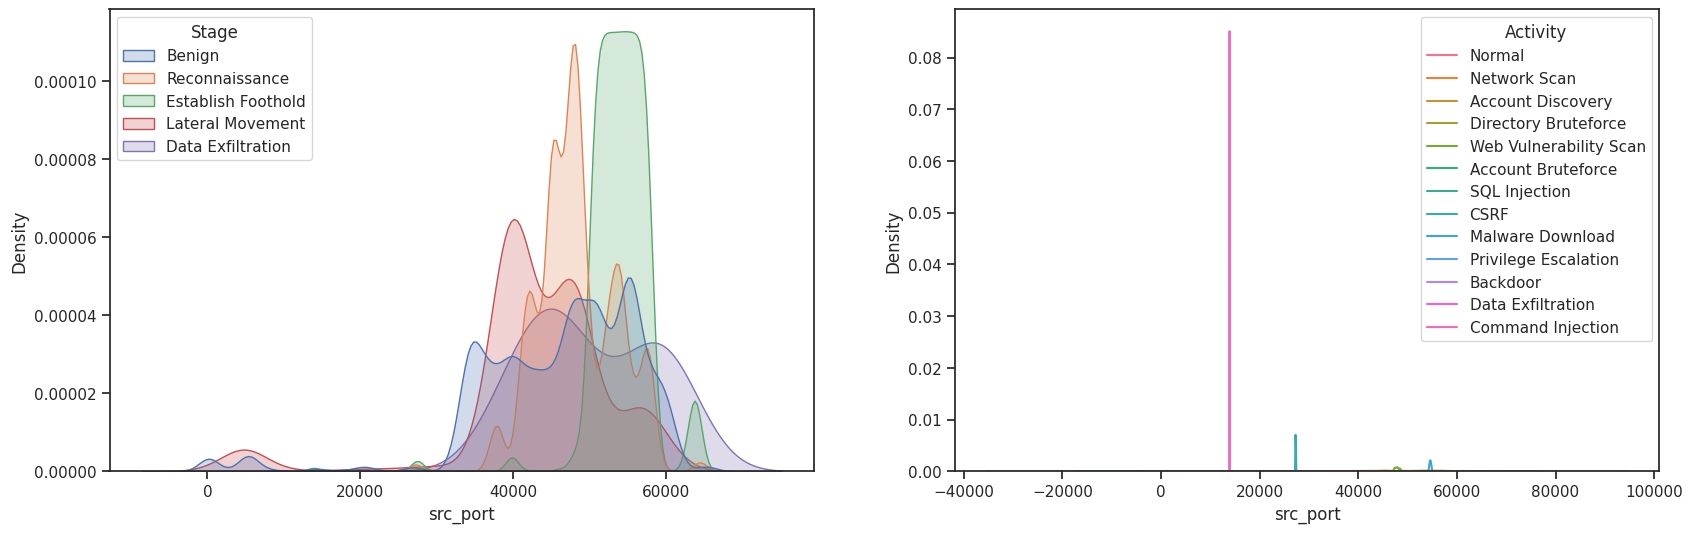

/tmp/ipykernel_9325/2658147167.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=plot_metrics, x=feature, hue='Activity', fill=False, common_norm=False, ax=ax2)


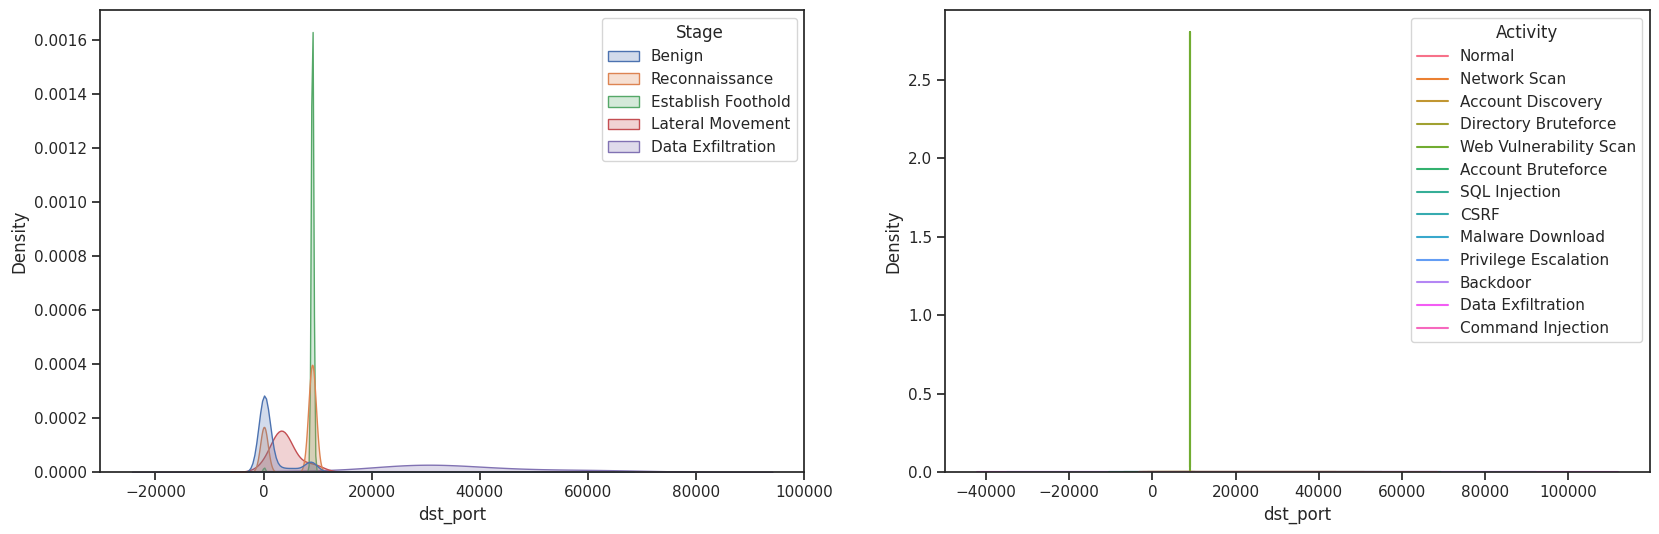

/tmp/ipykernel_9325/2658147167.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=plot_metrics, x=feature, hue='Stage', fill=True, common_norm=False, ax=ax1)
/tmp/ipykernel_9325/2658147167.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=plot_metrics, x=feature, hue='Activity', fill=False, common_norm=False, ax=ax2)


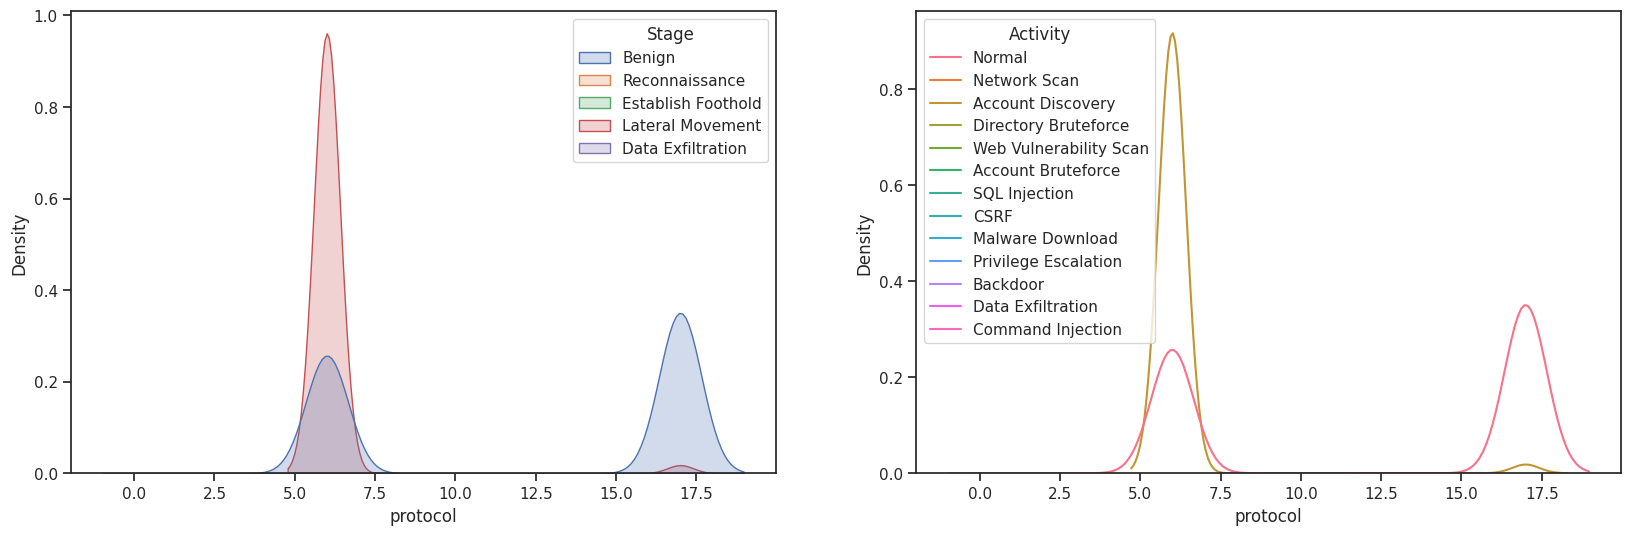

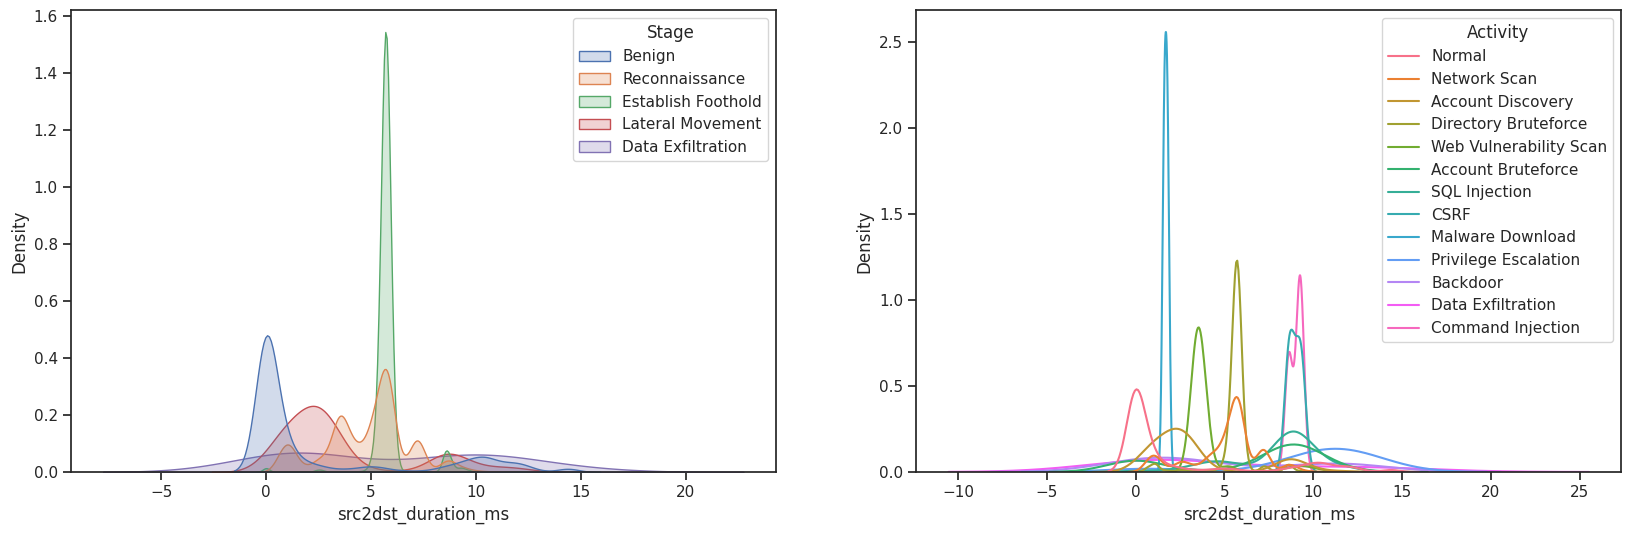

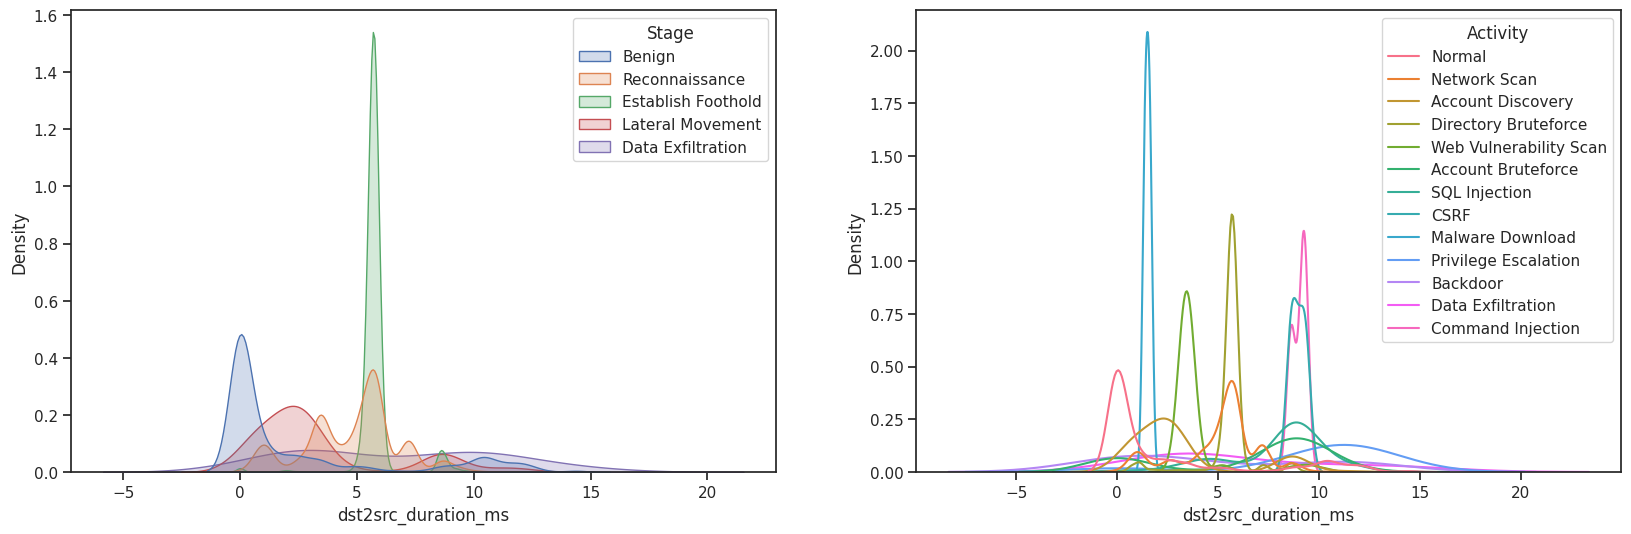

/tmp/ipykernel_9325/2658147167.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=plot_metrics, x=feature, hue='Activity', fill=False, common_norm=False, ax=ax2)


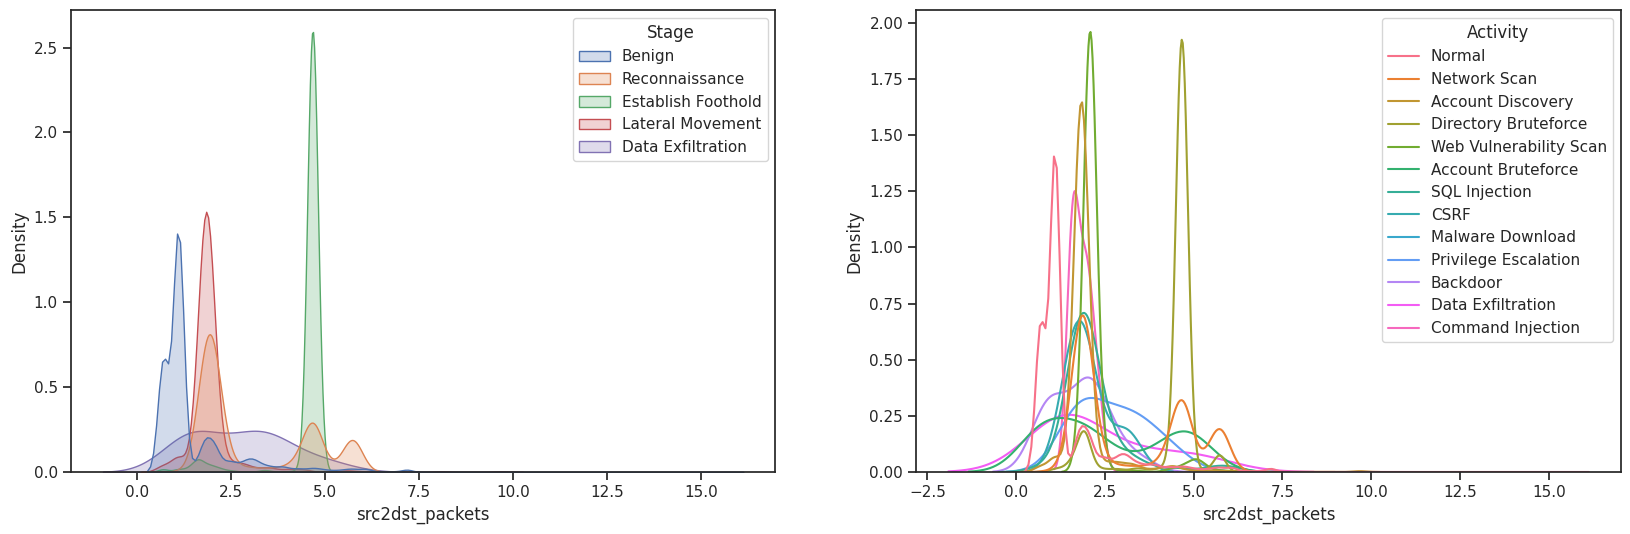

/tmp/ipykernel_9325/2658147167.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=plot_metrics, x=feature, hue='Activity', fill=False, common_norm=False, ax=ax2)


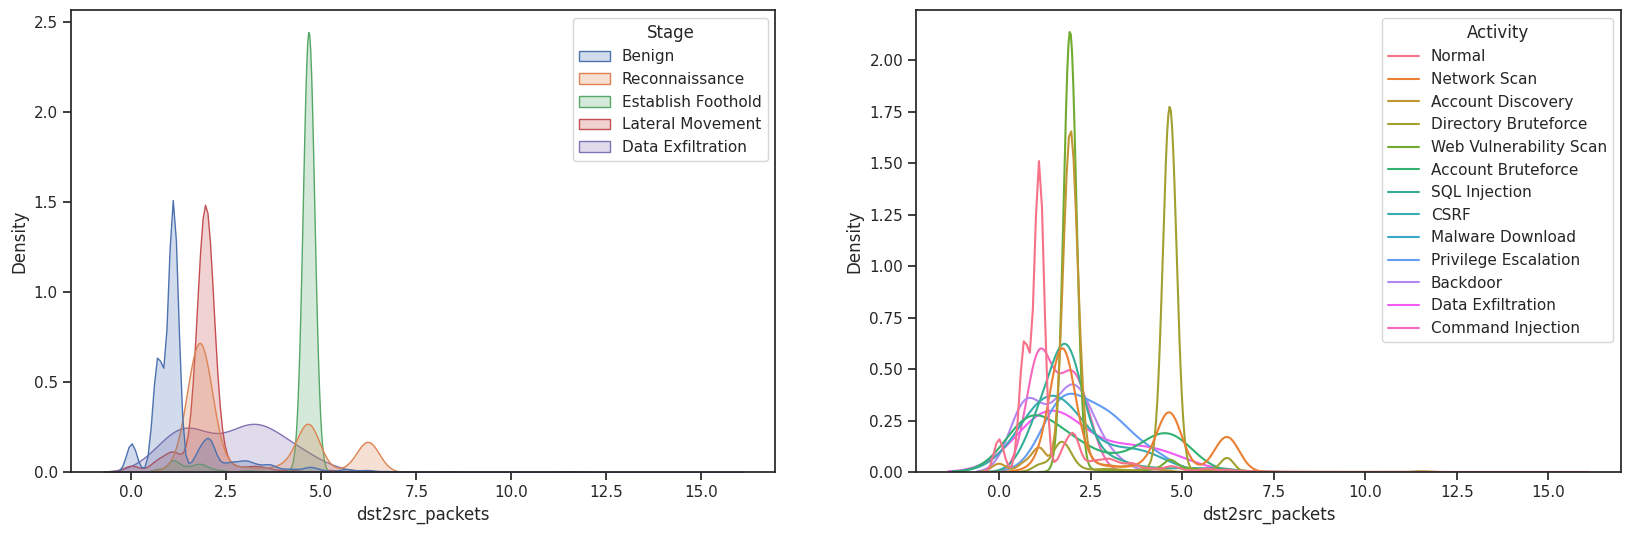

/tmp/ipykernel_9325/2658147167.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=plot_metrics, x=feature, hue='Activity', fill=False, common_norm=False, ax=ax2)


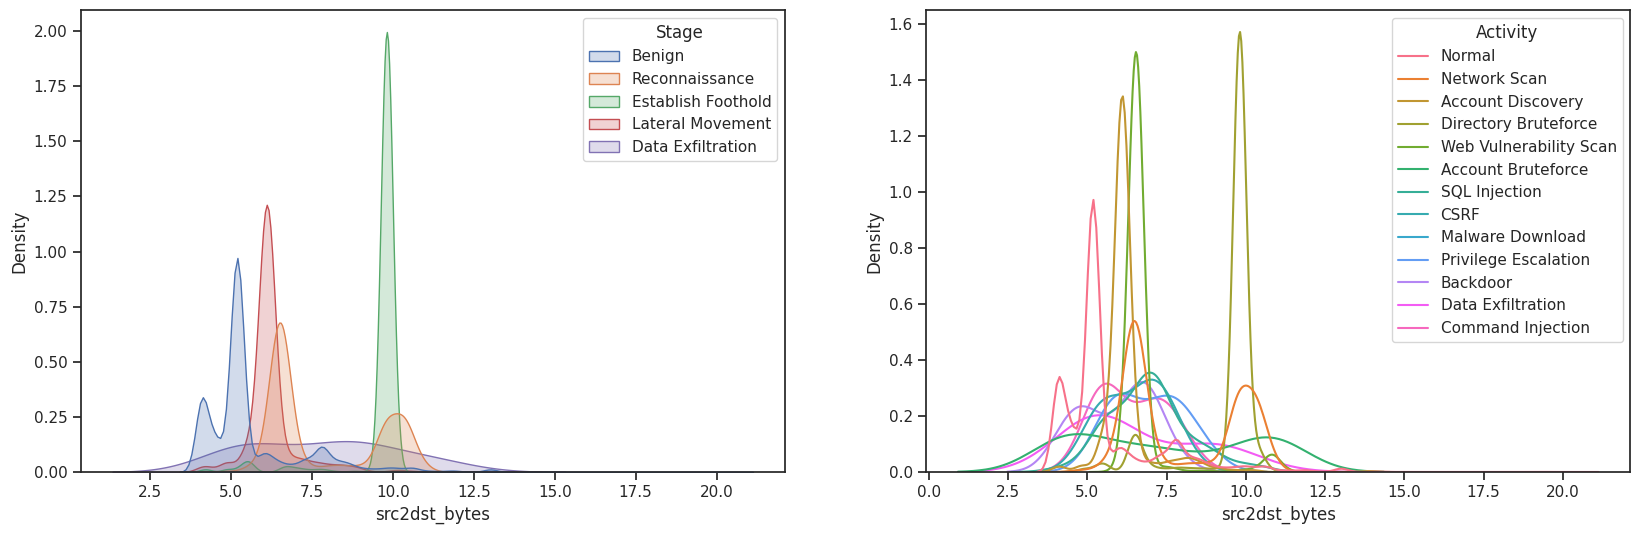

/tmp/ipykernel_9325/2658147167.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=plot_metrics, x=feature, hue='Activity', fill=False, common_norm=False, ax=ax2)


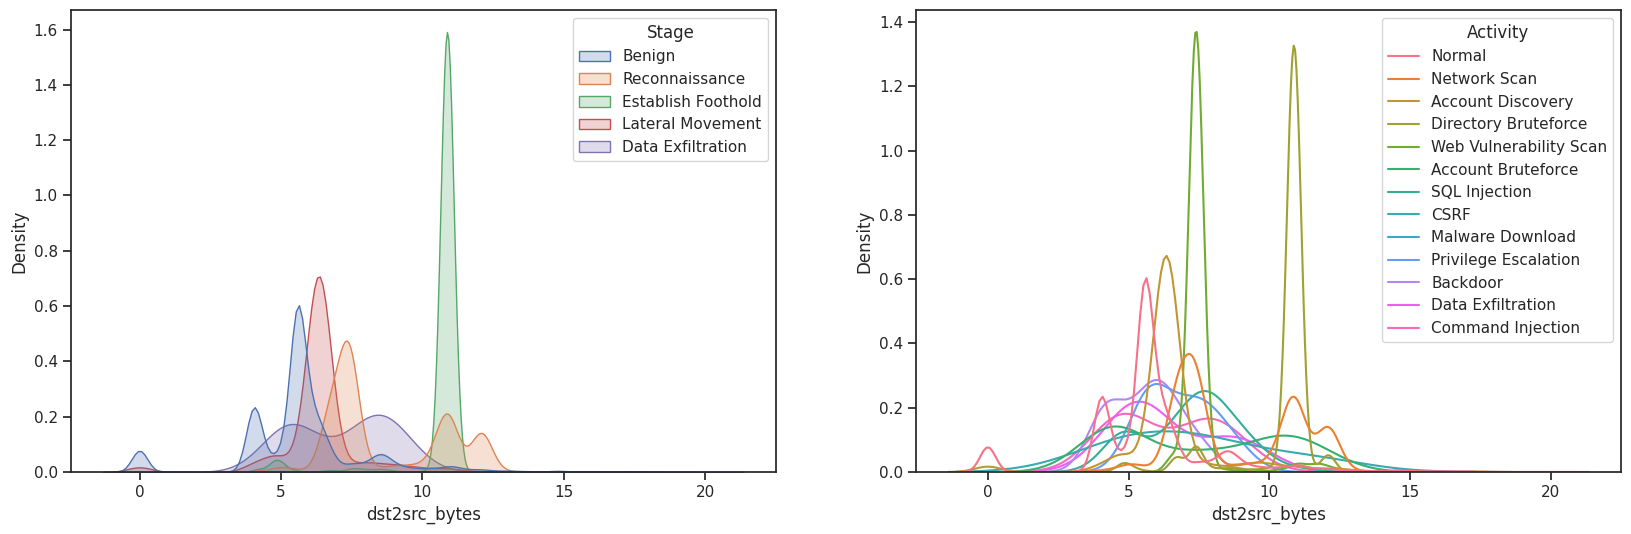

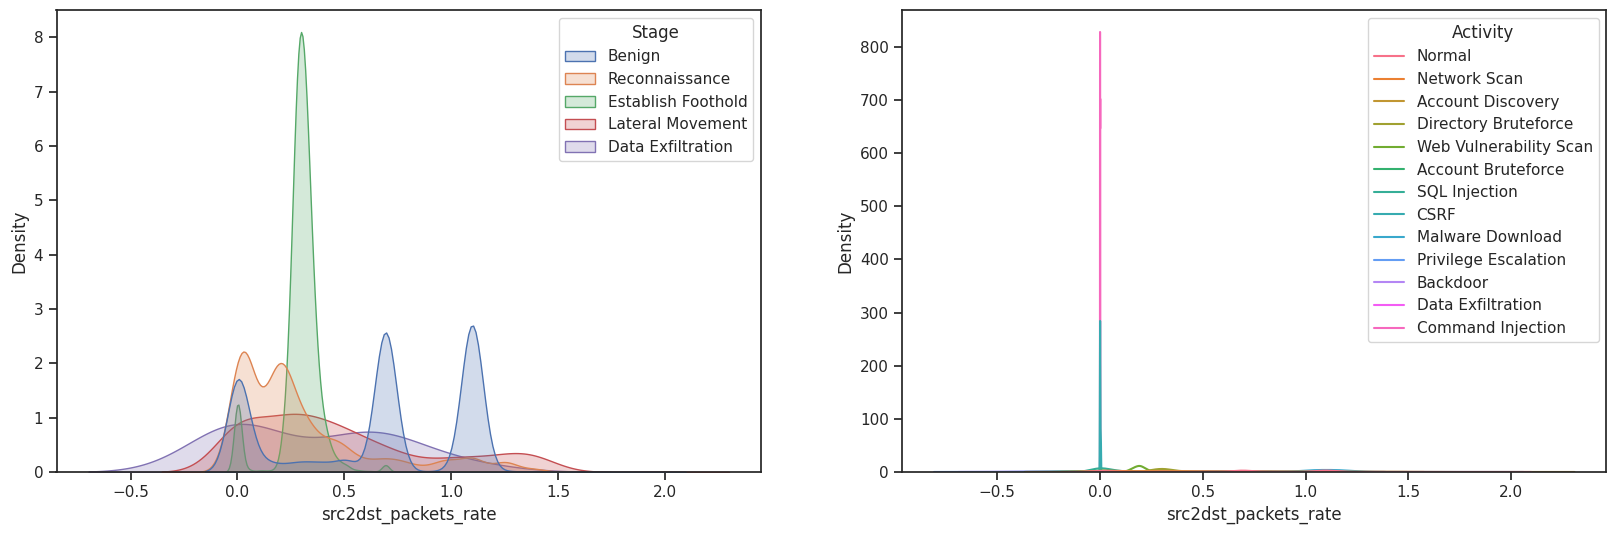

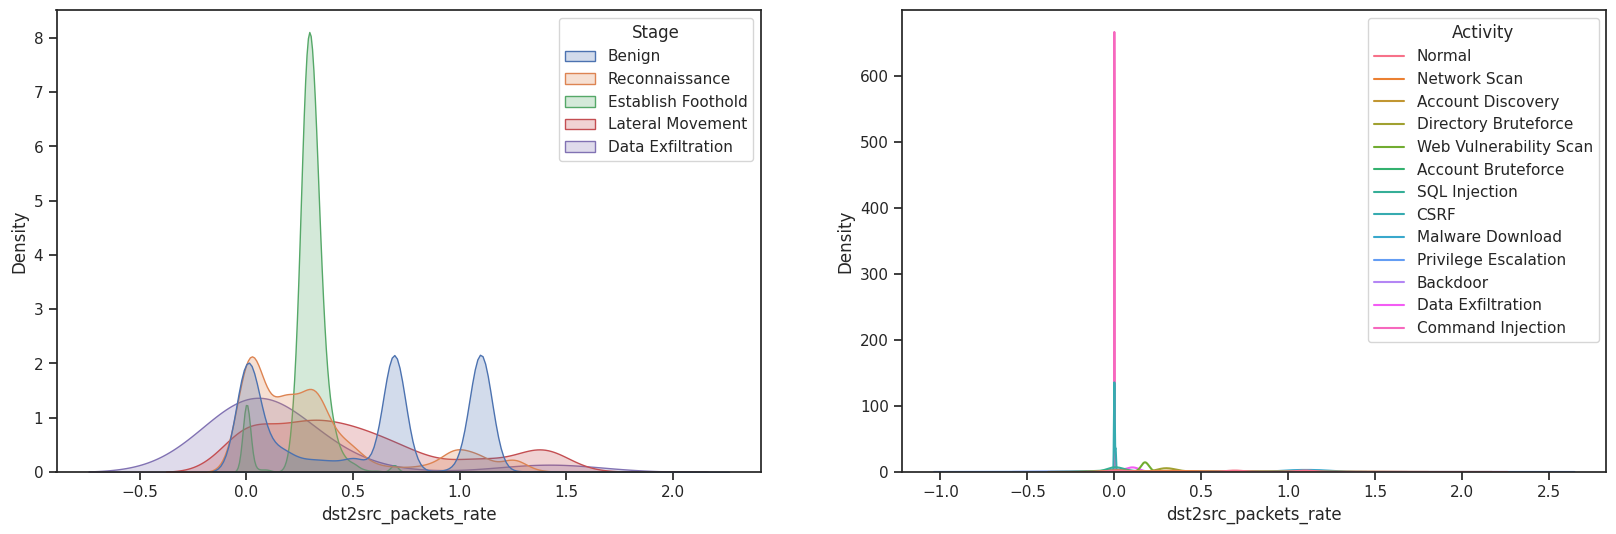

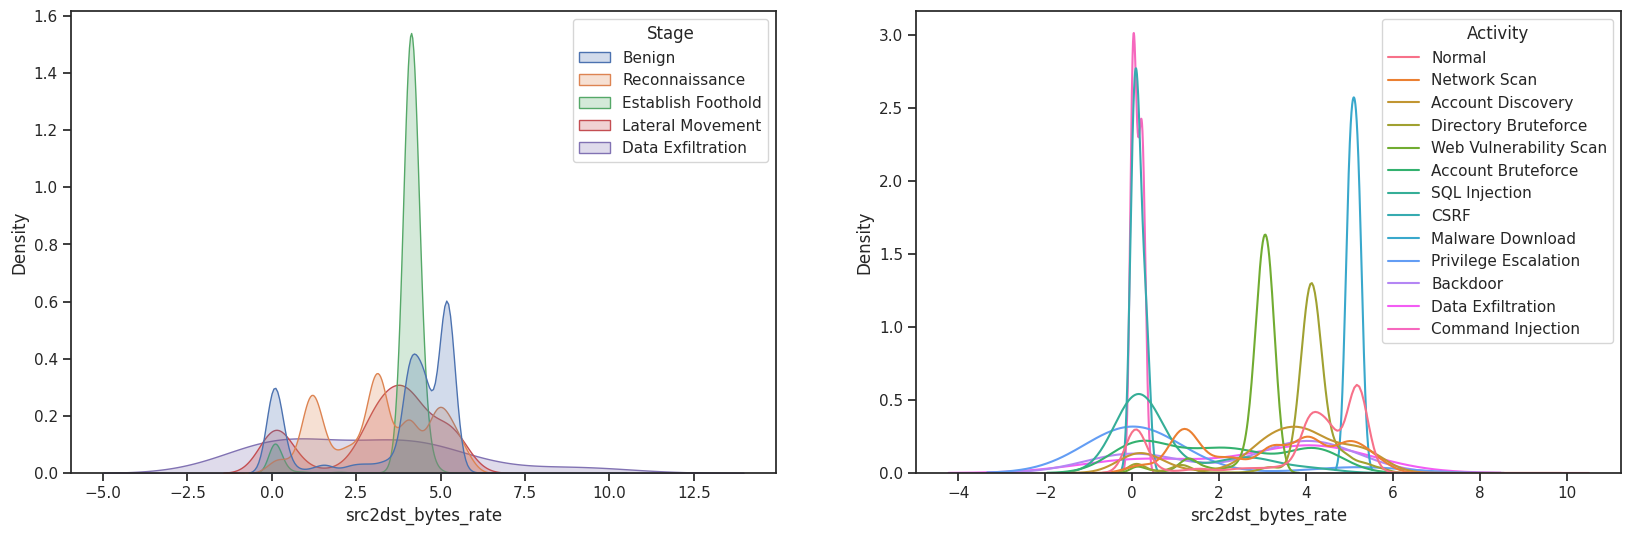

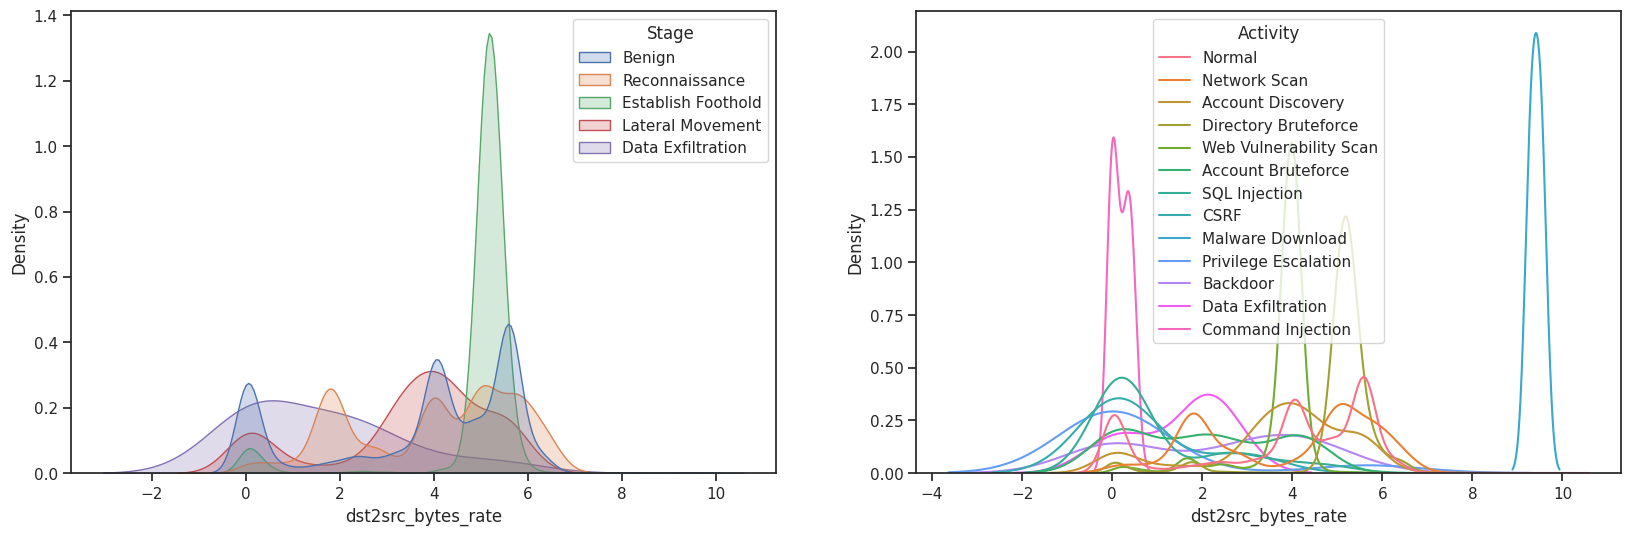

In [69]:
plot_metrics = pd.DataFrame()
plot_metrics['src_port'] = flows['src_port']
plot_metrics['dst_port'] = flows['dst_port']
plot_metrics['protocol'] = flows['protocol']
plot_metrics['src2dst_duration_ms'] = np.log(flows['src2dst_duration_ms'] + 1)
plot_metrics['dst2src_duration_ms'] = np.log(flows['dst2src_duration_ms'] + 1)
plot_metrics['src2dst_packets'] = np.log(flows['src2dst_packets'] + 1)
plot_metrics['dst2src_packets'] = np.log(flows['dst2src_packets'] + 1)
plot_metrics['src2dst_bytes'] = np.log(flows['src2dst_bytes'] + 1)
plot_metrics['dst2src_bytes'] = np.log(flows['dst2src_bytes'] + 1)
plot_metrics['src2dst_packets_rate'] = np.log(flows['src2dst_packets'] / (flows['src2dst_duration_ms'] + 1) + 1)
plot_metrics['dst2src_packets_rate'] = np.log(flows['dst2src_packets'] / (flows['dst2src_duration_ms'] + 1) + 1)
plot_metrics['src2dst_bytes_rate'] = np.log(flows['src2dst_bytes'] / (flows['src2dst_duration_ms'] + 1) + 1)
plot_metrics['dst2src_bytes_rate'] = np.log(flows['dst2src_bytes'] / (flows['dst2src_duration_ms'] + 1) + 1)
plot_metrics['Activity'] = flows['Activity']
plot_metrics['Stage'] = flows['Stage']

for feature in plot_metrics.columns:
    if not pd.api.types.is_numeric_dtype(plot_metrics[feature]):
        continue
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    sns.kdeplot(data=plot_metrics, x=feature, hue='Stage', fill=True, common_norm=False, ax=ax1)
    sns.kdeplot(data=plot_metrics, x=feature, hue='Activity', fill=False, common_norm=False, ax=ax2)
    plt.show()

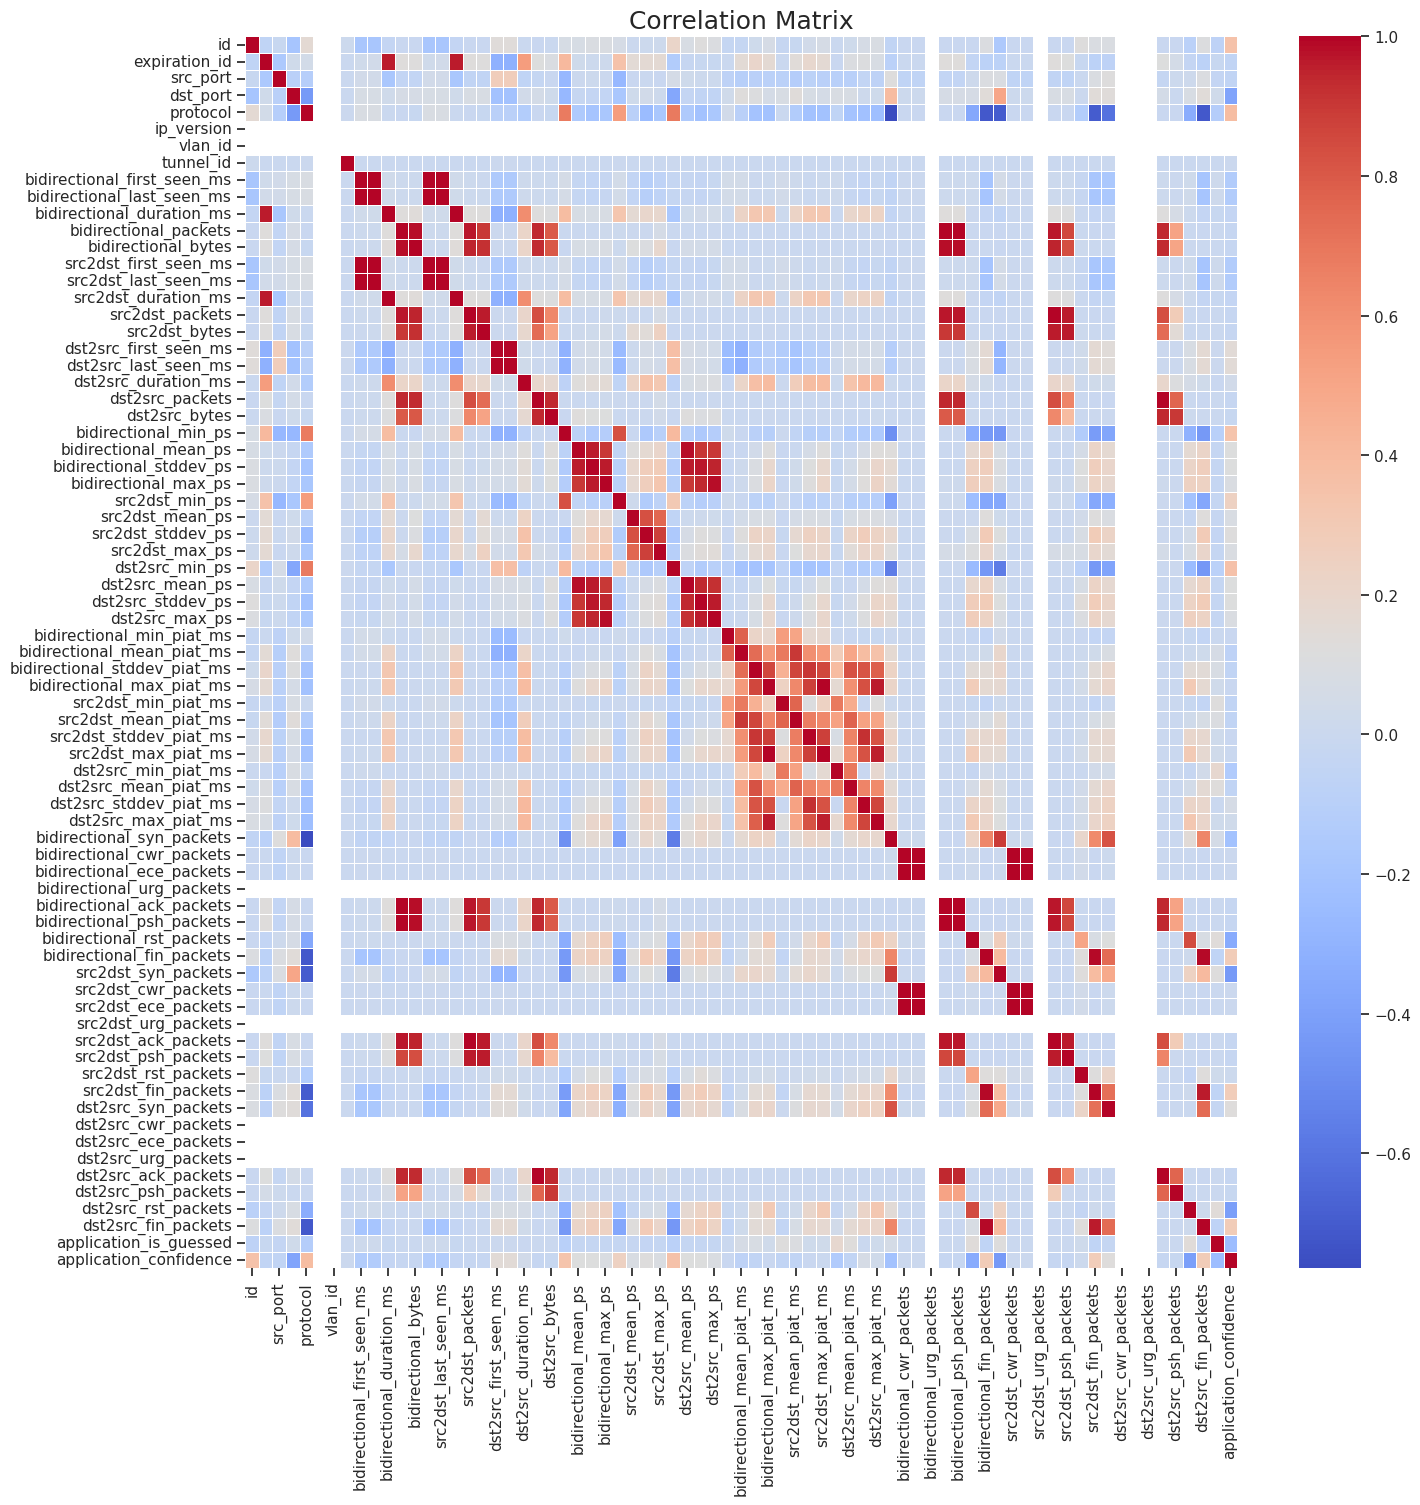

In [55]:
correlation = flows.corr(numeric_only=True)

fig, ax = plt.subplots(figsize = (16, 16))
sns.heatmap(correlation, cmap = 'coolwarm', annot = False, linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 18)
plt.show()